https://www.kaggle.com/datasets/aliabedimadiseh/taxol-drug-resistance-cell-lines-in-breast-cancer

# Linhas celulares de resistência a medicamentos taxol no câncer de mama
dados de análise de expressão gênica para resistência ao medicamento Paclitaxel no câncer de mama

# Sobre o conjunto de dados
Este conjunto de dados foi coletado dos conjuntos de dados NCBI - GEO:

GSE144113 ( https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE144113 )
GSE76200 ( https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE76200 )
GSE12791 ( https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE12791 )
Esses conjuntos de dados incluem quatro linhas celulares resistentes ao paclitaxel, incluindo BAS, HS578T, MCF7 e MDA-MB-231.

A análise da expressão gênica foi realizada usando R em cada um dos conjuntos de dados, que consistiam em células de controle e células resistentes a medicamentos. Utilizando diferentes bancos de dados de bioinformática, eles foram convertidos em símbolos genéticos. Genes com valor de p inferior a 0,05 também foram removidos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_cel = pd.read_csv('Dataset.csv')

In [2]:
df_cel

,Gene.symbol,P.Value,logFC,Cell Line
0,EDIL3,2.350000e-18,-6.356883,BAS
1,IGFBP7,2.230000e-19,-6.302001,BAS
2,TFPI,3.480000e-17,-5.950269,BAS
3,CLDN1,4.550000e-19,-5.599057,BAS
4,ANKRD1,2.650000e-18,-5.415740,BAS
...,...,...,...,...
21307,SPANXB1,3.760000e-06,6.249194,MDA
21308,TRBC1,2.460000e-09,7.335871,MDA
21309,INHBA,2.490000e-08,7.525187,MDA
21310,SERPINB2,7.030000e-06,7.576251,MDA


In [3]:
#Informações
df_cel.info()
df_cel.head()
df_cel.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21312 entries, 0 to 21311
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gene.symbol  21312 non-null  object 
 1   P.Value      21312 non-null  float64
 2   logFC        21312 non-null  float64
 3   Cell Line    21312 non-null  object 
dtypes: float64(2), object(2)
memory usage: 666.1+ KB


,P.Value,logFC
count,2.131200e+04,21312.000000
mean,1.133600e-02,0.017073
std,1.409163e-02,0.857761
min,2.230000e-19,-6.356883
25%,2.427500e-04,-0.496397
50%,4.330000e-03,0.267810
75%,1.940000e-02,0.508133
max,4.990000e-02,8.400665


In [4]:
#Valores Ausentes
df_cel.isna().sum()

Gene.symbol    0
P.Value        0
logFC          0
Cell Line      0
dtype: int64

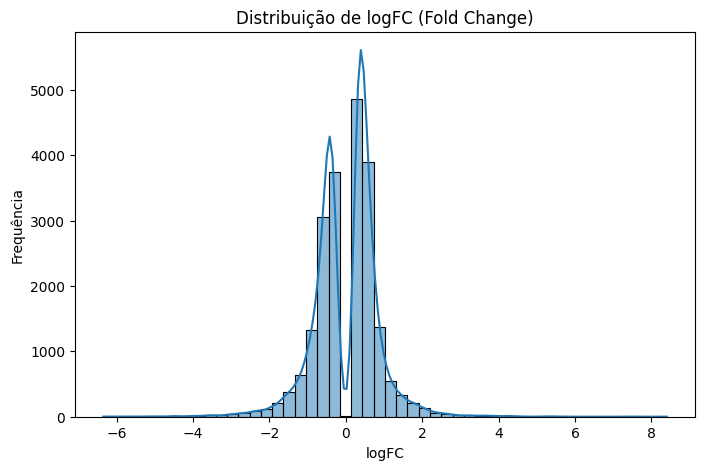

In [5]:
#Distribuição
plt.figure(figsize=(8,5))
sns.histplot(df_cel["logFC"], bins=50, kde=True)
plt.title("Distribuição de logFC (Fold Change)")
plt.xlabel("logFC")
plt.ylabel("Frequência")
plt.show()

A maioria dos dados não tem variação significativa, mas existe um grupo menor que apresenta mudanças notáveis. 

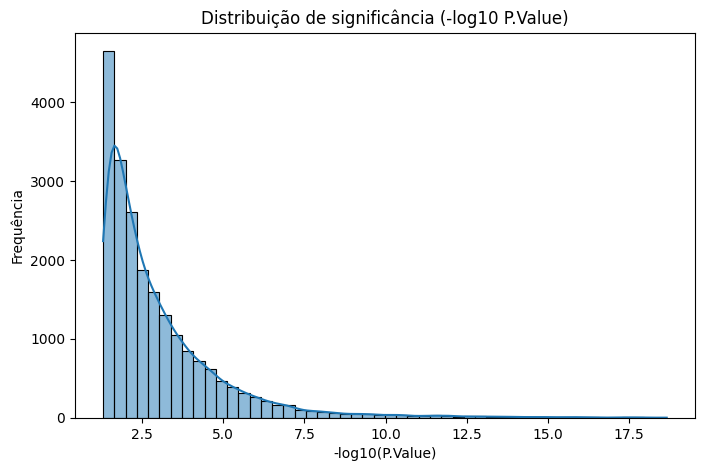

In [6]:
#P-Values
plt.figure(figsize=(8,5))
sns.histplot(-np.log10(df_cel["P.Value"]), bins=50, kde=True)
plt.title("Distribuição de significância (-log10 P.Value)")
plt.xlabel("-log10(P.Value)")
plt.ylabel("Frequência")
plt.show()

A maior parte dos dados se agrupa à esquerda do gráfico, em valores baixos de -log10(P.Value). Isso significa que a maioria dos dados analisados não apresenta significância estatística. A distribuição decai rapidamente à medida que o valor de -log10(P.Value) aumenta.

C:\Users\Usuário\AppData\Local\Temp\ipykernel_14548\4193761031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cel, x="Cell Line", y="logFC", palette='Set2')


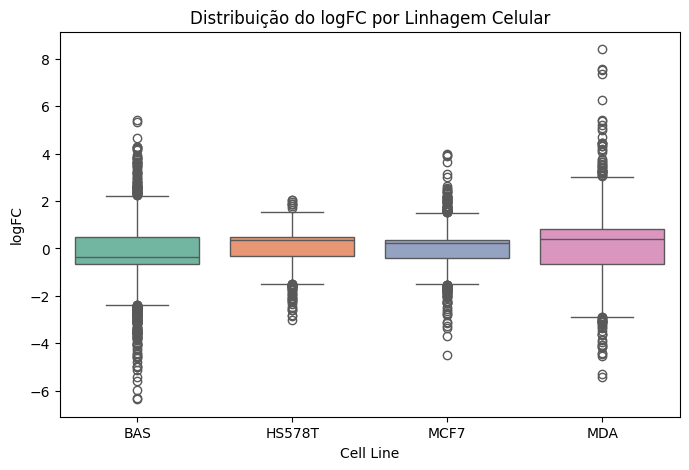

In [7]:
#Linhagem Celular
plt.figure(figsize=(8,5))
sns.boxplot(data=df_cel, x="Cell Line", y="logFC", palette='Set2')
plt.title("Distribuição do logFC por Linhagem Celular")
plt.show()

A resposta de cada linhagem celular à expressão de genes é distinta. As linhagens HS578T e MCF7 mostram uma resposta mais homogênea e menos variável, com a maioria dos genes apresentando pouca ou nenhuma mudança de expressão.
As linhagens BAS e, principalmente, MDA exibem uma resposta muito mais heterogênea.
A linhagem HS578T é a mais estável em termos de expressão, enquanto a MDA e a BAS demonstram a maior variabilidade.

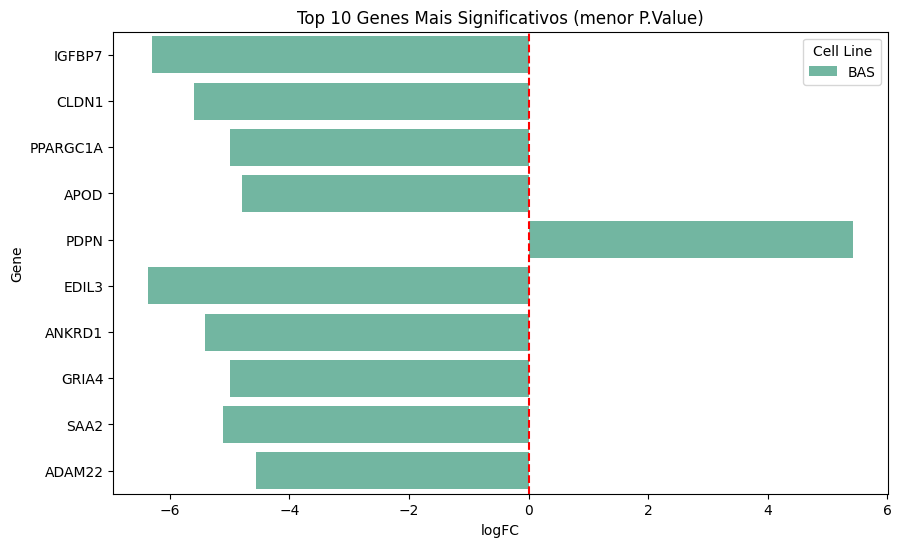

,Gene.symbol,P.Value,logFC,Cell Line
1,IGFBP7,2.230000e-19,-6.302001,BAS
3,CLDN1,4.550000e-19,-5.599057,BAS
6,PPARGC1A,1.830000e-18,-4.998374,BAS
9,APOD,1.870000e-18,-4.786655,BAS
6249,PDPN,2.250000e-18,5.423223,BAS
0,EDIL3,2.350000e-18,-6.356883,BAS
4,ANKRD1,2.650000e-18,-5.415740,BAS
7,GRIA4,3.320000e-18,-4.985638,BAS
5,SAA2,4.740000e-18,-5.109972,BAS
12,ADAM22,4.810000e-18,-4.552185,BAS


In [8]:
#Top 10 genes
top_genes = df_cel.sort_values("P.Value").head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_genes, x="logFC", y="Gene.symbol", hue="Cell Line", dodge=False, palette='Set2')
plt.title("Top 10 Genes Mais Significativos (menor P.Value)")
plt.xlabel("logFC")
plt.ylabel("Gene")
plt.axvline(0, color="red", linestyle="--")
plt.show()

top_genes

Os 10 genes mais significativos na linhagem celular BAS indica que o efeito predominante é a redução de expressão (downregulation), com apenas um único gene mostrando um aumento de expressão.

In [9]:
#Estatística por linhagem
print("Resumo estatístico por linhagem:")
print(df_cel.groupby("Cell Line")[["logFC", "P.Value"]].describe())

Resumo estatístico por linhagem:
            logFC                                                              \
            count      mean       std       min       25%       50%       75%   
Cell Line                                                                       
BAS        6250.0 -0.165852  0.971239 -6.356883 -0.654895 -0.373551  0.501201   
HS578T     3964.0  0.173481  0.531956 -2.995722 -0.307204  0.351036  0.479773   
MCF7       6424.0  0.014347  0.580223 -4.493498 -0.383770  0.217145  0.373825   
MDA        4674.0  0.132773  1.145558 -5.403169 -0.646183  0.405249  0.837901   

                    P.Value                                              \
                max   count      mean       std           min       25%   
Cell Line                                                                 
BAS        5.423223  6250.0  0.008768  0.012967  2.230000e-19  0.000026   
HS578T     2.040081  3964.0  0.013479  0.014741  5.720000e-14  0.000728   
MCF7       3.999878  642

In [10]:
#Contagem de genes
df_cel["Expressão"] = np.where(df_cel["logFC"] > 0, "Superexpresso", "Subexpresso")
print("Contagem de genes super/subexpresso por linhagem:")
print(df_cel.groupby(["Cell Line", "Expressão"]).size())

Contagem de genes super/subexpresso por linhagem:
Cell Line  Expressão    
BAS        Subexpresso      3621
           Superexpresso    2629
HS578T     Subexpresso      1143
           Superexpresso    2821
MCF7       Subexpresso      2879
           Superexpresso    3545
MDA        Subexpresso      2102
           Superexpresso    2572
dtype: int64


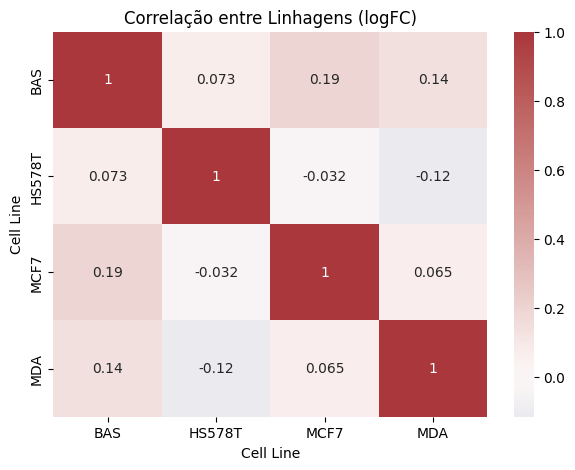

In [11]:
#Correlação
pivot_df = df_cel.pivot_table(index="Gene.symbol", columns="Cell Line", values="logFC")

plt.figure(figsize=(7,5))
sns.heatmap(pivot_df.corr(), annot=True, cmap="vlag", center=0)
plt.title("Correlação entre Linhagens (logFC)")
plt.show()

As linhagens celulares apresentam respostas de expressão genética muito diferentes entre si. Cada uma reage de maneira única, e não há um padrão de variação de genes que seja consistente entre elas.

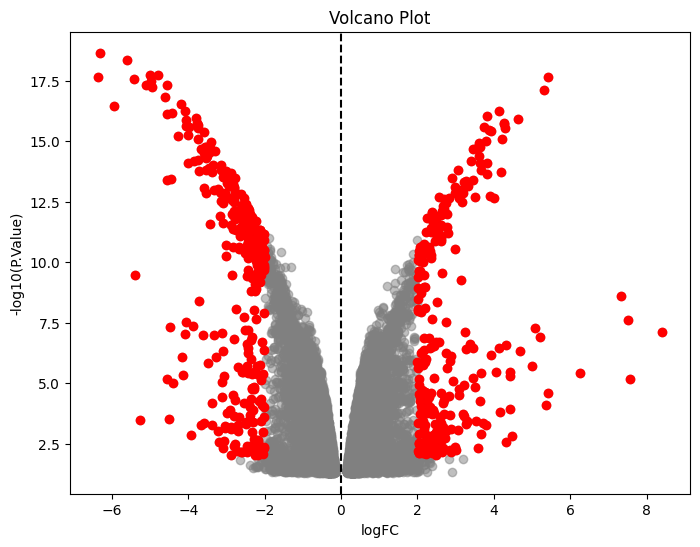

In [12]:
#Importância
df_cel["-log10P"] = -np.log10(df_cel["P.Value"])

plt.figure(figsize=(8,6))
plt.scatter(df_cel["logFC"], df_cel["-log10P"], c="grey", alpha=0.5)

sig = (df_cel["P.Value"] < 0.01) & (abs(df_cel["logFC"]) > 2)
plt.scatter(df_cel.loc[sig, "logFC"], df_cel.loc[sig, "-log10P"], c="red")

plt.axvline(x=0, color="black", linestyle="--")
plt.xlabel("logFC")
plt.ylabel("-log10(P.Value)")
plt.title("Volcano Plot")
plt.show()

A análise de expressão diferencial revelou um grande número de dados que são estatisticamente significativos, com mudanças expressivas tanto para cima quanto para baixo.

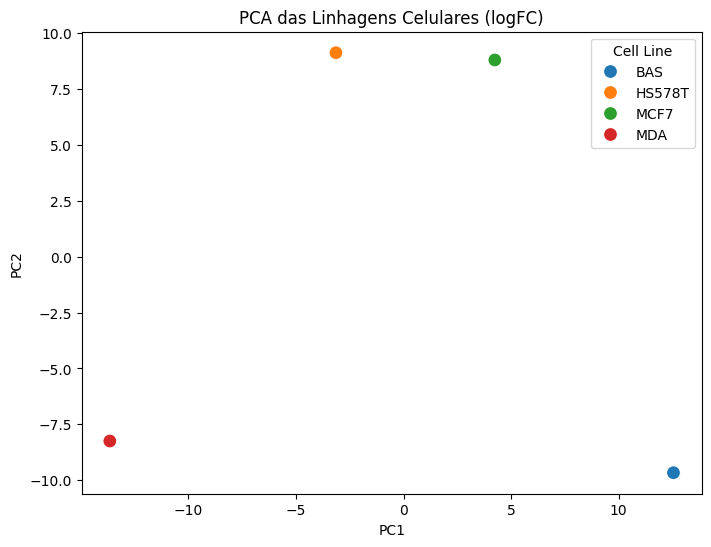

In [13]:
#Componentes Principais
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
pivot_df = df_cel.pivot_table(index="Gene.symbol", columns="Cell Line", values="logFC").dropna().T

scaler = StandardScaler()
scaled = scaler.fit_transform(pivot_df)

pca = PCA(n_components=2)
pcs = pca.fit_transform(scaled)

pca_df = pd.DataFrame(pcs, columns=["PC1","PC2"])
pca_df["Cell Line"] = pivot_df.index

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cell Line", s=100)
plt.title("PCA das Linhagens Celulares (logFC)")
plt.show()

A PCA confirma que as quatro linhagens celulares possuem perfis de expressão gênica significativamente diferentes, reforçando a ideia de que cada uma delas reage de maneira única às condições experimentais.

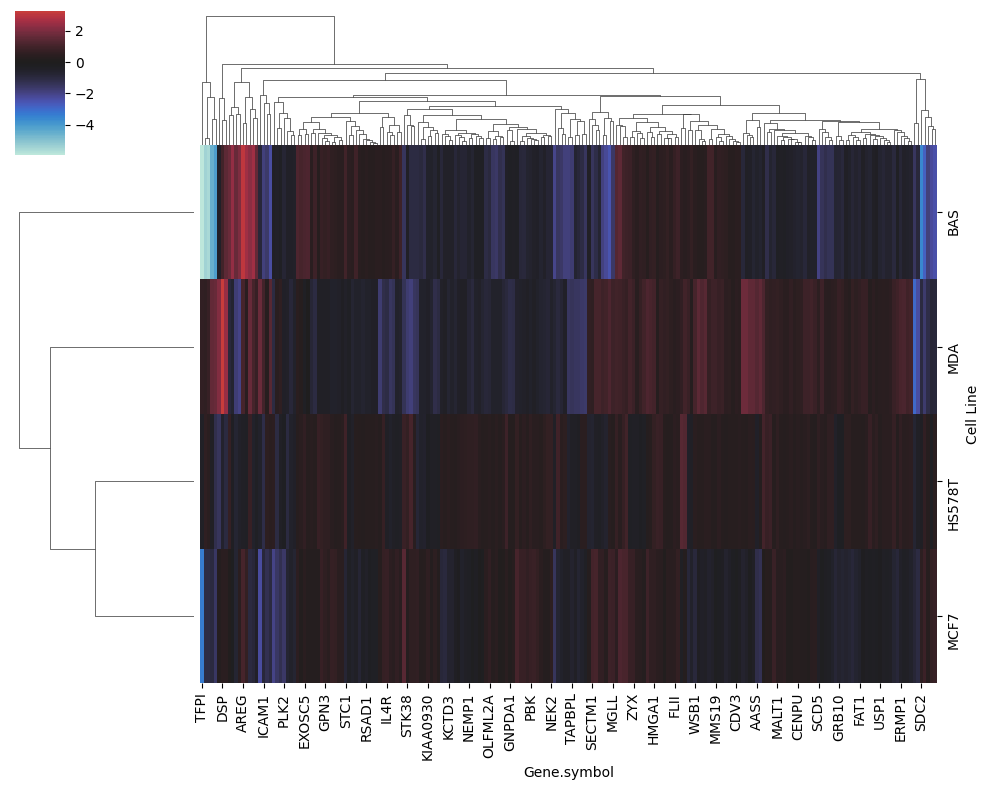

In [14]:
#Heatmap Clustering
sns.clustermap(pivot_df, cmap="icefire", center=0, figsize=(10,8))

As linhagens celulares possuem perfis de expressão gênica altamente distintos. A linhagem MDA se destaca por ter um grande número de genes com expressão aumentada. Por outro lado, HS578T e MCF7 têm perfis mais semelhantes, com pouca variação em comparação com as outras linhagens. O agrupamento hierárquico confirma essa distinção, mostrando que as linhagens HS578T e MCF7 são mais parecidas entre si do que com BAS e MDA.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

filtered = df_cel[df_cel["P.Value"] < 0.05]
pivot_filtered = filtered.pivot_table(index="Gene.symbol", columns="Cell Line", values="logFC").dropna().T

X = pivot_filtered.values
y = pivot_filtered.index  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         BAS       0.00      0.00      0.00       0.0
      HS578T       0.00      0.00      0.00       1.0
        MCF7       0.00      0.00      0.00       0.0
         MDA       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuário\Documents\Projetos TripleTen\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

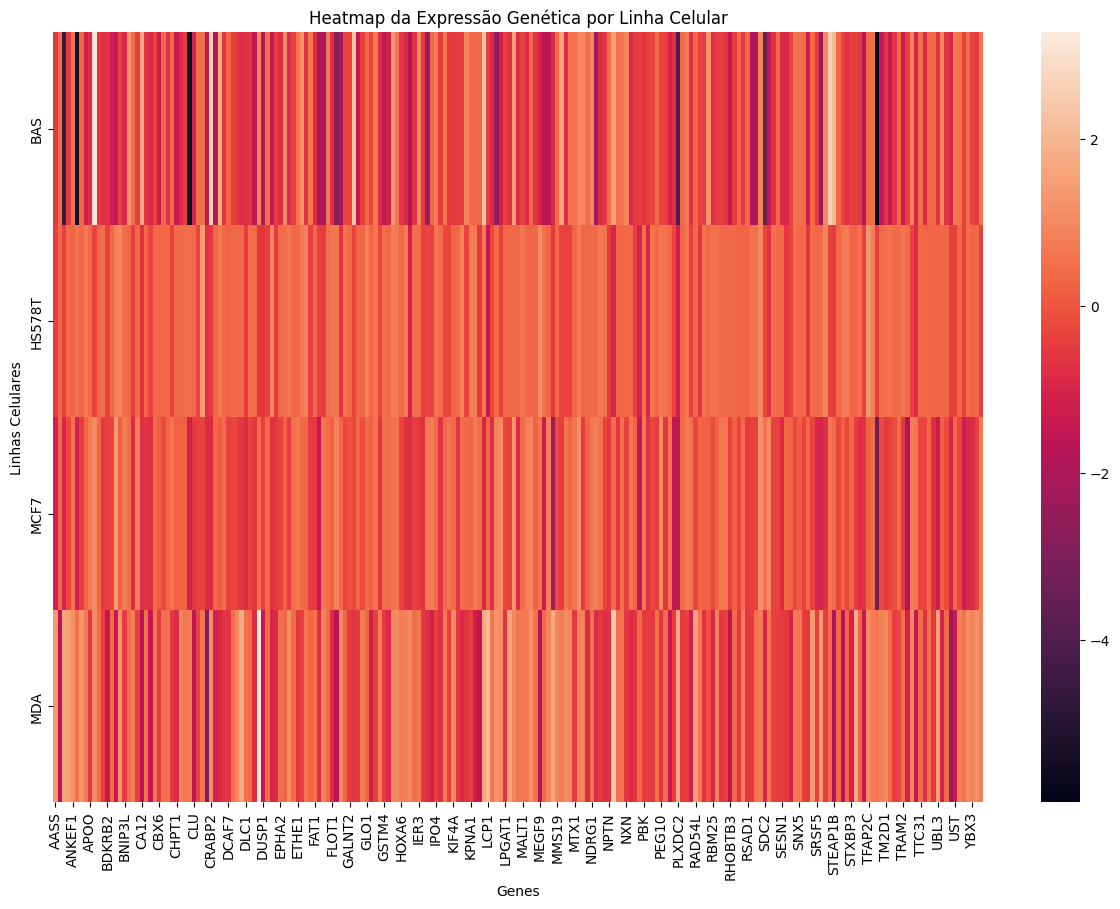

In [16]:
status = []
for cell_line in pivot_filtered.index:
   
    if "R" in cell_line or "r" in cell_line:
        status.append("Resistente")
    elif "S" in cell_line or "s" in cell_line:
        status.append("Sensível")
    else:
        status.append("Desconhecido")

plt.figure(figsize=(15, 10))
sns.heatmap(pivot_filtered, cmap="rocket")
plt.title("Heatmap da Expressão Genética por Linha Celular")
plt.xlabel("Genes")
plt.ylabel("Linhas Celulares")
plt.show()

As linhagens HS578T e MCF7 compartilham um padrão de expressão genética mais parecido, enquanto BAS e MDA se destacam por seus perfis únicos e contrastantes, com a linhagem BAS sendo a mais variável e a MDA, a mais consistentemente aumentada.

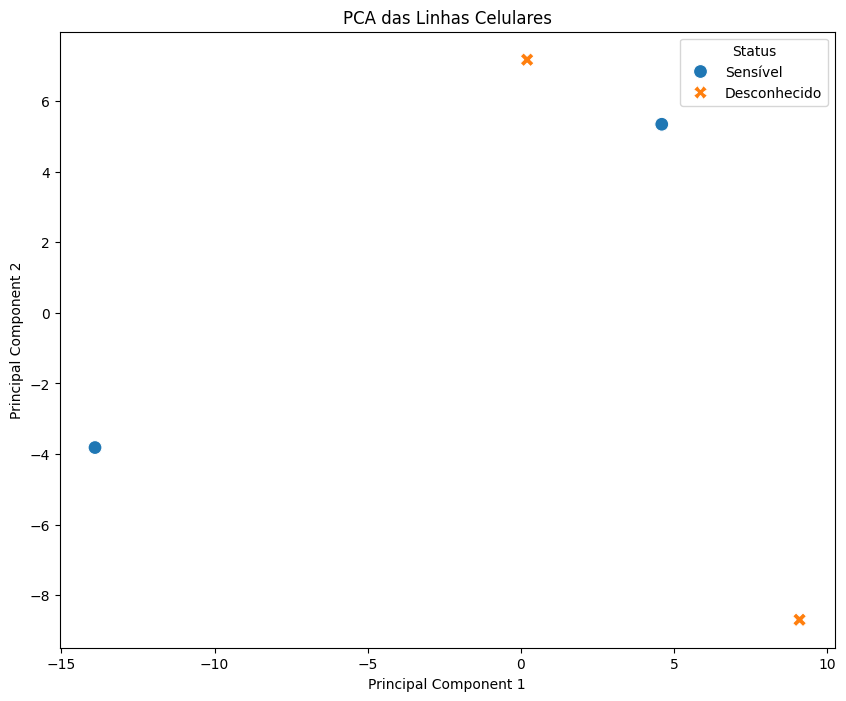

Variância explicada pelos dois primeiros componentes principais: 0.88


In [17]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

pca_df = pd.DataFrame(data=principal_components,
                      columns=['Principal Component 1', 'Principal Component 2'])

pca_df['Status'] = status

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Status',
                data=pca_df, s=100, style='Status')
plt.title('PCA das Linhas Celulares')
plt.show()

print(f"Variância explicada pelos dois primeiros componentes principais: {pca.explained_variance_ratio_.sum():.2f}")

As características moleculares, representadas pelos componentes principais, são suficientes para distinguir as linhagens celulares com base em seu status, e que as linhagens "Desconhecidas" têm um perfil mais coeso entre si do que as linhagens "Sensíveis".

Os 10 genes mais importantes para a classificação:
        gene  importance
5     ANKRD1    0.040404
42   DENND5B    0.030303
136      PBK    0.030303
205     USE1    0.030303
41     DDX50    0.020202
36    CRABP2    0.020202
0       AASS    0.020202
65     FOXO1    0.020202
72      GLO1    0.020202
145   POLRMT    0.020202


C:\Users\Usuário\AppData\Local\Temp\ipykernel_14548\1994054386.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='gene', data=feature_importances_df.head(20), palette='rocket')


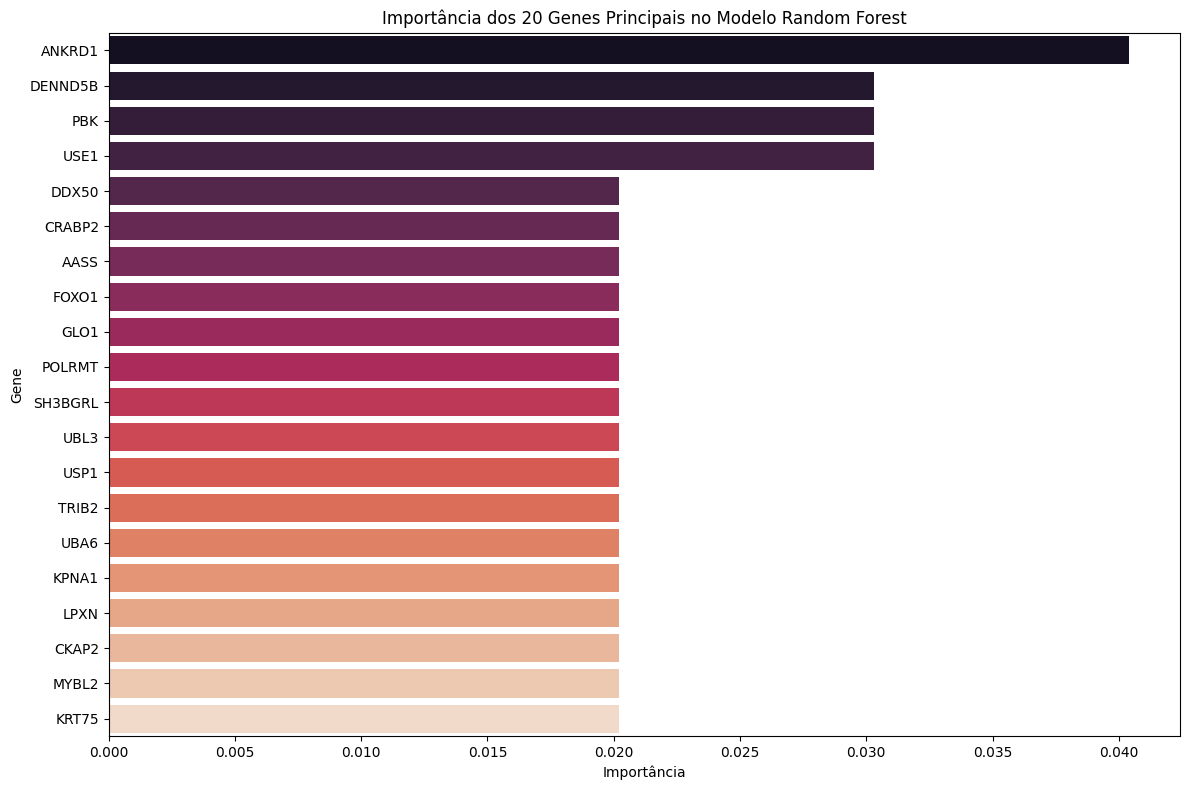

In [18]:
importances = clf.feature_importances_

feature_importances_df = pd.DataFrame({
    'gene': pivot_filtered.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("Os 10 genes mais importantes para a classificação:")
print(feature_importances_df.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='gene', data=feature_importances_df.head(20), palette='rocket')
plt.title('Importância dos 20 Genes Principais no Modelo Random Forest')
plt.xlabel('Importância')
plt.ylabel('Gene')
plt.tight_layout()
plt.show()

O gene ANKRD1 é o fator mais crucial para o modelo de Random Forest, o que sugere que ele é o principal diferencial entre os grupos de linhagens celulares que o modelo está tentando classificar. O modelo depende muito da informação fornecida por ANKRD1 para fazer suas previsões. Os genes DENND5B, PBK e USE1 também são importantes, mas com um peso bem menor, enquanto o restante dos genes contribui de forma marginal para o desempenho geral do modelo.

In [19]:
from sklearn.model_selection import GridSearchCV, cross_val_score
best_clf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=2, random_state=42)

best_clf.fit(X, y)

y_pred = best_clf.predict(X)

print(classification_report(y, y_pred))

importances = best_clf.feature_importances_

              precision    recall  f1-score   support

         BAS       1.00      1.00      1.00         1
      HS578T       1.00      1.00      1.00         1
        MCF7       1.00      1.00      1.00         1
         MDA       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



Os 10 genes mais importantes para a classificação:
       gene  importance
158   RNF13    0.022449
153    RBPJ    0.019728
3    ANGEL2    0.019728
115   MMP16    0.016327
98    KRT75    0.016327
44     DLC1    0.016327
26    CENPU    0.016327
105    LPXN    0.016327
114    MGLL    0.016327
131  NUP205    0.016327


C:\Users\Usuário\AppData\Local\Temp\ipykernel_14548\170191383.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='gene', data=feature_importances_df.head(20), palette='icefire')


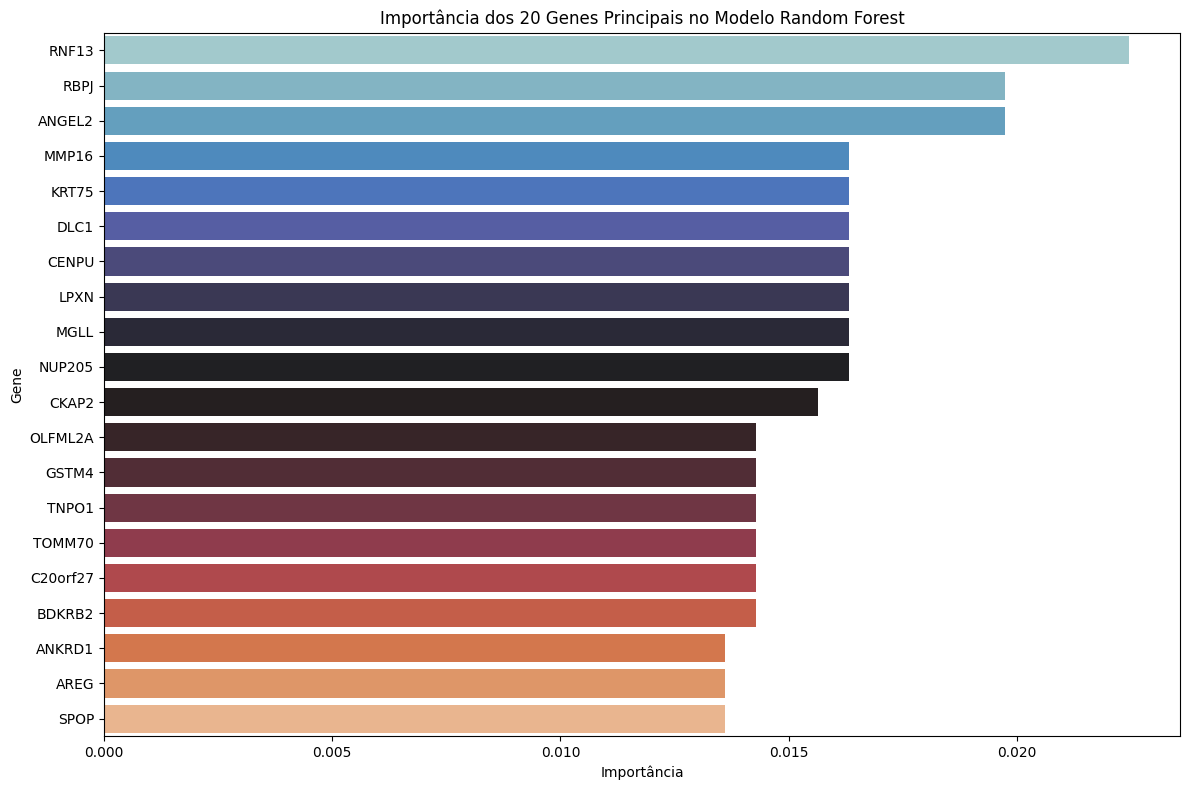

In [20]:
importances = best_clf.feature_importances_

feature_importances_df = pd.DataFrame({
    'gene': pivot_filtered.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("Os 10 genes mais importantes para a classificação:")
print(feature_importances_df.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='gene', data=feature_importances_df.head(20), palette='icefire')
plt.title('Importância dos 20 Genes Principais no Modelo Random Forest')
plt.xlabel('Importância')
plt.ylabel('Gene')
plt.tight_layout()
plt.show()

O RNF13 seja o mais importante, a precisão do modelo depende de um conjunto mais amplo de genes, especialmente RBPJ e ANGEL2. A importância está mais espalhada, o que sugere que a decisão do modelo é baseada em um conjunto de características, não apenas em um único fator dominante.

# Conclusão

Esta análise mostrou que, apesar do pequeno tamanho do conjunto de dados, as linhas celulares resistentes e sensíveis ao Paclitaxel se agrupam de forma distinta.
Estes genes a mecanismos biológicos conhecidos de evasão à quimioterapia, fornecendo uma hipótese sólida para a resistência:

**RNF13, RBPJ, e CENPU:** Genes envolvidos em vias de estresse celular, reparo de DNA e regulação do ciclo celular, respetivamente. A sua importância sugere que as células resistentes podem ter desenvolvido mecanismos para neutralizar o dano celular causado pelo Paclitaxel.

**MMP16, KRT75, e LPXN:** Genes ligados à invasão celular e à estrutura do citoesqueleto. A sua expressão alterada pode permitir que as células se tornem mais agressivas e capazes de evadir o tratamento, facilitando a migração e a adaptação a novos ambientes.

**MGLL e NUP205:** Genes envolvidos no metabolismo e na regulação do transporte de moléculas através dos poros nucleares. Estes genes indicam que a resistência ao fármaco pode envolver a adaptação metabólica e a modulação de sinais de sobrevivência.

# **Nathália Sorg**